In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

In [4]:
df = pd.read_csv("WineQT.csv")
print(df)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1138            6.3             0.510         0.13             2.3      0.076   
1139            6.8             0.620         0.08             1.9      0.068   
1140            6.2             0.600         0.08             2.0      0.090   
1141            5.9             0.550         0.10             2.2      0.062   
1142            5.9             0.645         0.12             2.0      0.075   

      free sulfur dioxide  

In [5]:
print(df.isna().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [6]:
kolom_numerik = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

z_scores = np.abs(stats.zscore(df[kolom_numerik]))
outliers = (z_scores > 3).any(axis=1)

print("Jumlah outlier:", np.sum(outliers))

Jumlah outlier: 102


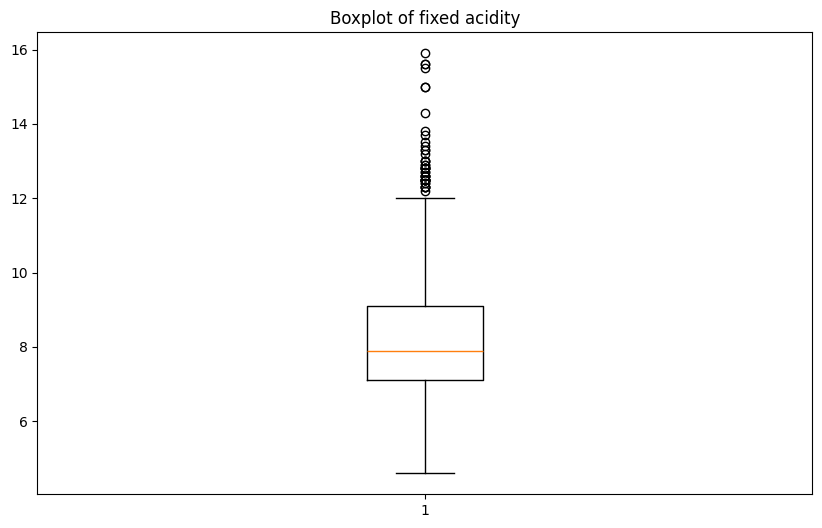

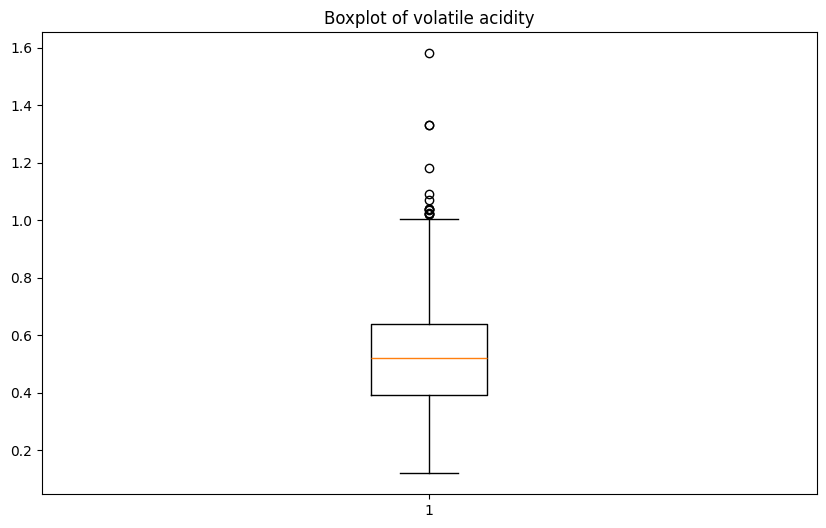

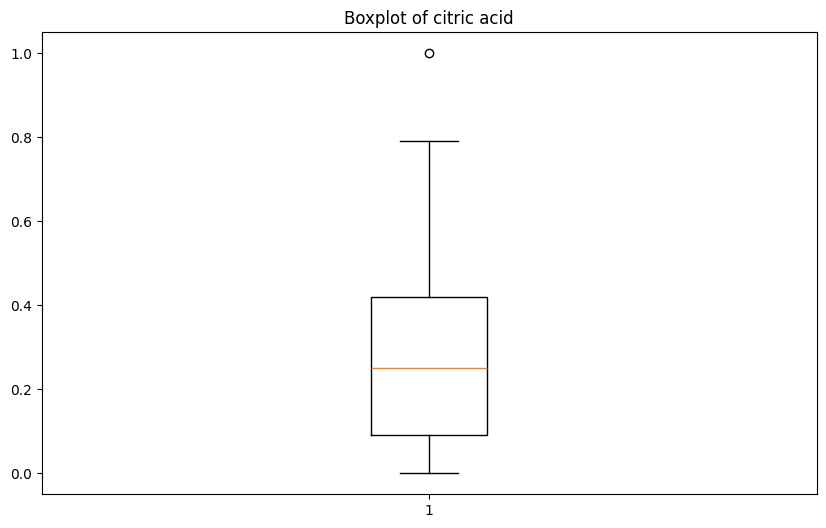

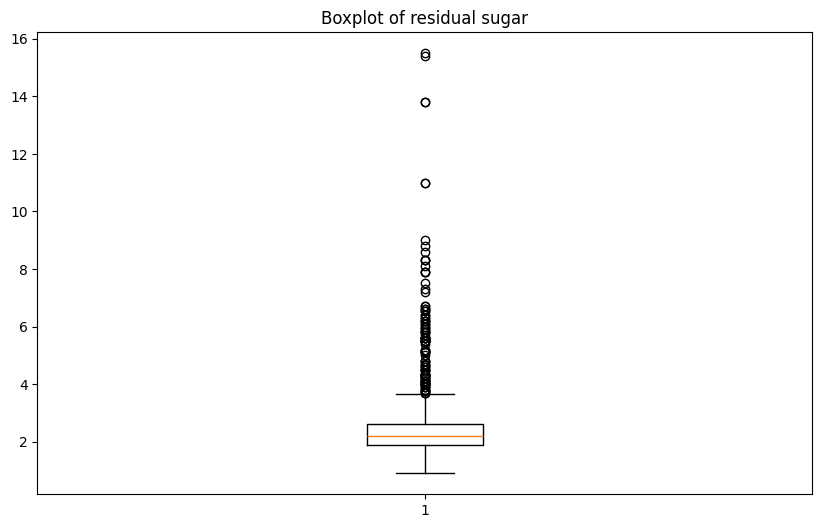

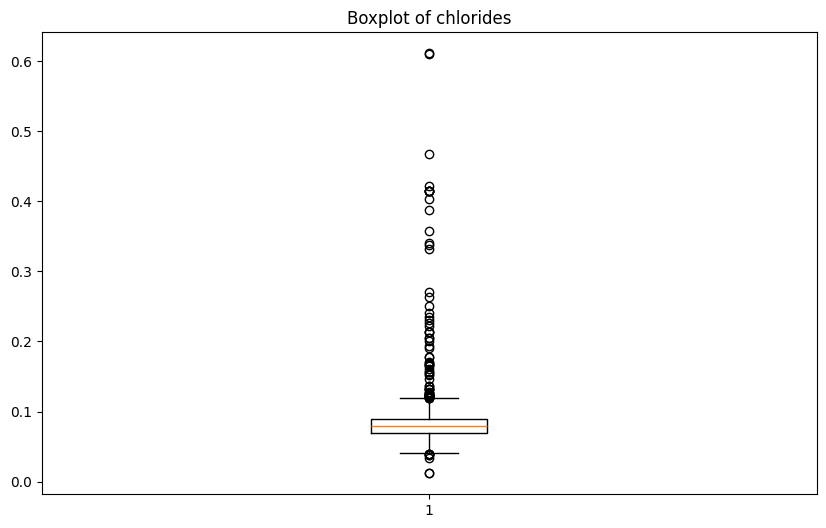

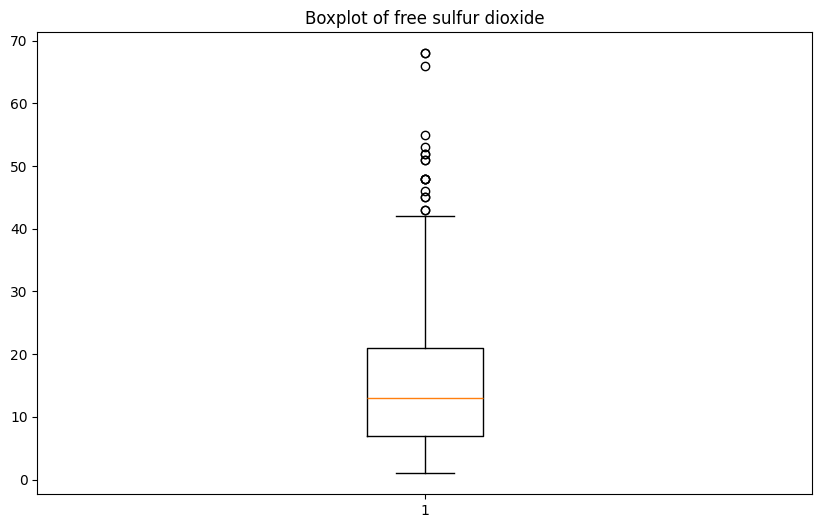

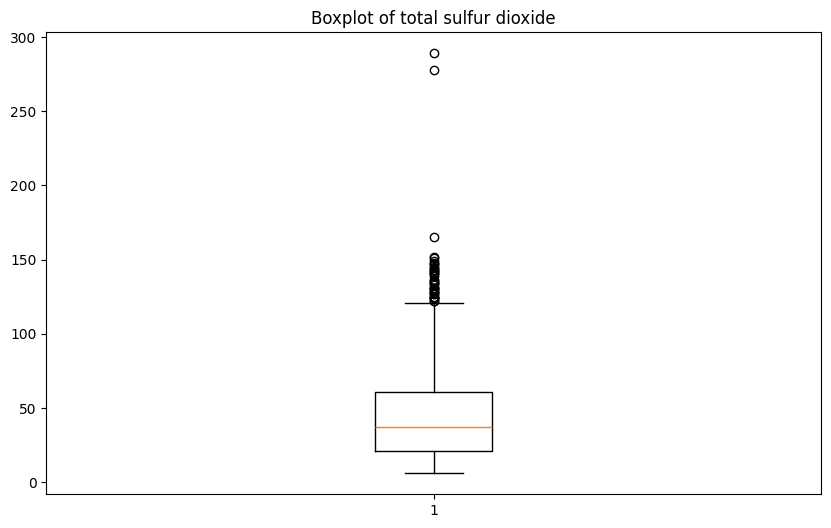

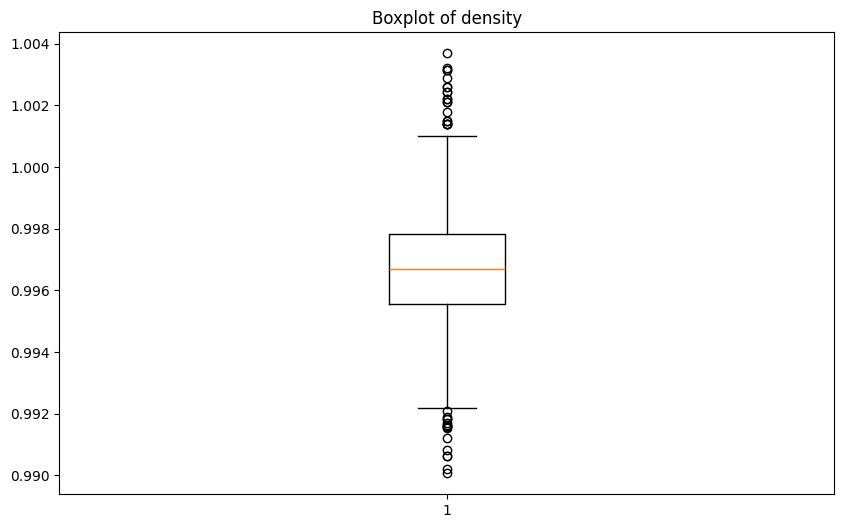

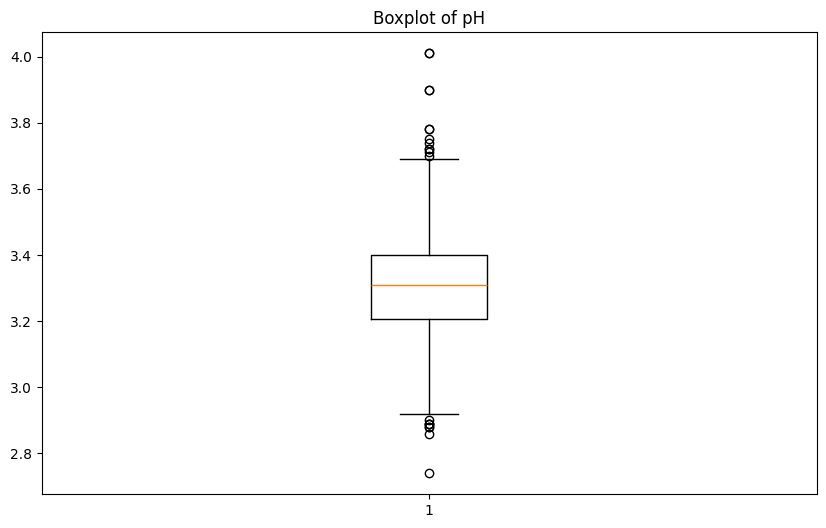

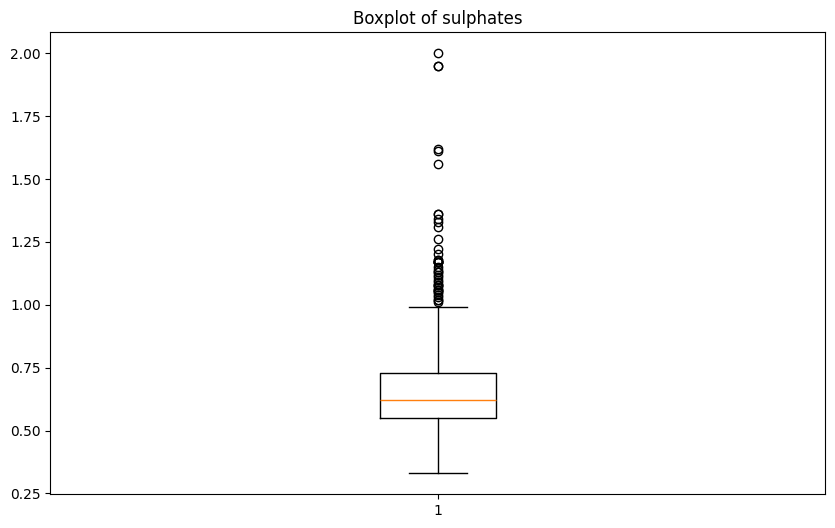

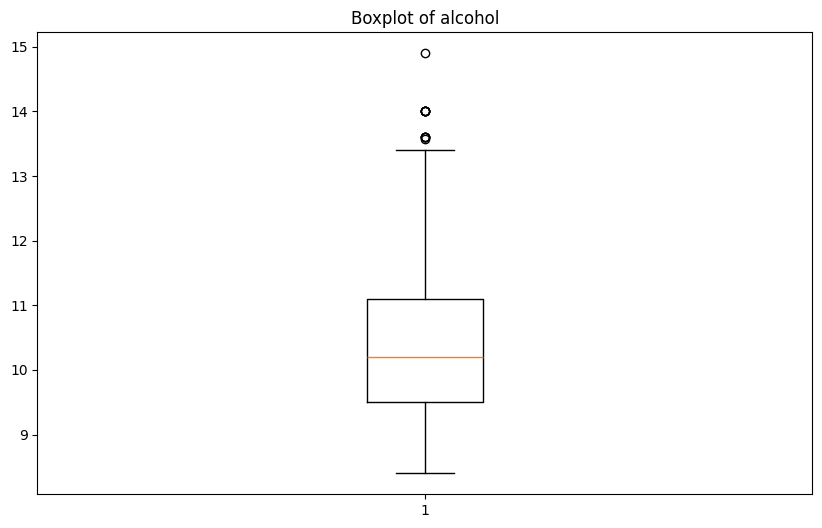

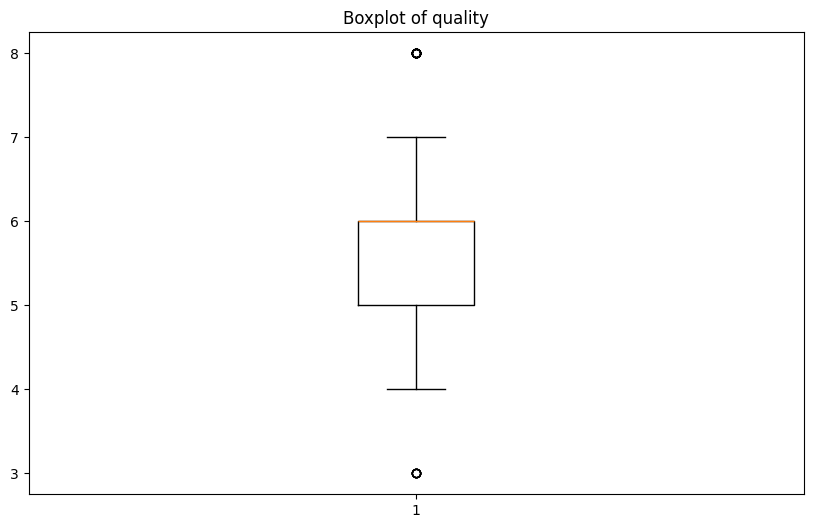

In [11]:
for col in kolom_numerik:
    plt.figure(figsize=(10, 6))
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [8]:
df_cleaned = df.copy()

total_removed = 0
iteration = 0

while True:
    
    iteration += 1
    
    z_scores = np.abs(stats.zscore(df_cleaned[kolom_numerik]))
    outliers = (z_scores > 3).any(axis=1)
    
    n_outliers = np.sum(outliers)
    
    print(f"Iterasi {iteration}")
    print("Jumlah outlier ditemukan:", n_outliers)
    
    if n_outliers == 0:
        break
    
    df_cleaned = df_cleaned[~outliers].copy()
    
    total_removed += n_outliers
    
    print("Jumlah baris setelah pembersihan:", len(df_cleaned))
    print("-"*40)

print("Proses selesai")
print("Total baris yang dibuang:", total_removed)
print("Total baris yang tersisa:", len(df_cleaned))

Iterasi 1
Jumlah outlier ditemukan: 102
Jumlah baris setelah pembersihan: 1041
----------------------------------------
Iterasi 2
Jumlah outlier ditemukan: 101
Jumlah baris setelah pembersihan: 940
----------------------------------------
Iterasi 3
Jumlah outlier ditemukan: 53
Jumlah baris setelah pembersihan: 887
----------------------------------------
Iterasi 4
Jumlah outlier ditemukan: 28
Jumlah baris setelah pembersihan: 859
----------------------------------------
Iterasi 5
Jumlah outlier ditemukan: 11
Jumlah baris setelah pembersihan: 848
----------------------------------------
Iterasi 6
Jumlah outlier ditemukan: 1
Jumlah baris setelah pembersihan: 847
----------------------------------------
Iterasi 7
Jumlah outlier ditemukan: 0
Proses selesai
Total baris yang dibuang: 296
Total baris yang tersisa: 847


In [9]:
print(df_cleaned)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1138            6.3             0.510         0.13             2.3      0.076   
1139            6.8             0.620         0.08             1.9      0.068   
1140            6.2             0.600         0.08             2.0      0.090   
1141            5.9             0.550         0.10             2.2      0.062   
1142            5.9             0.645         0.12             2.0      0.075   

      free sulfur dioxide  

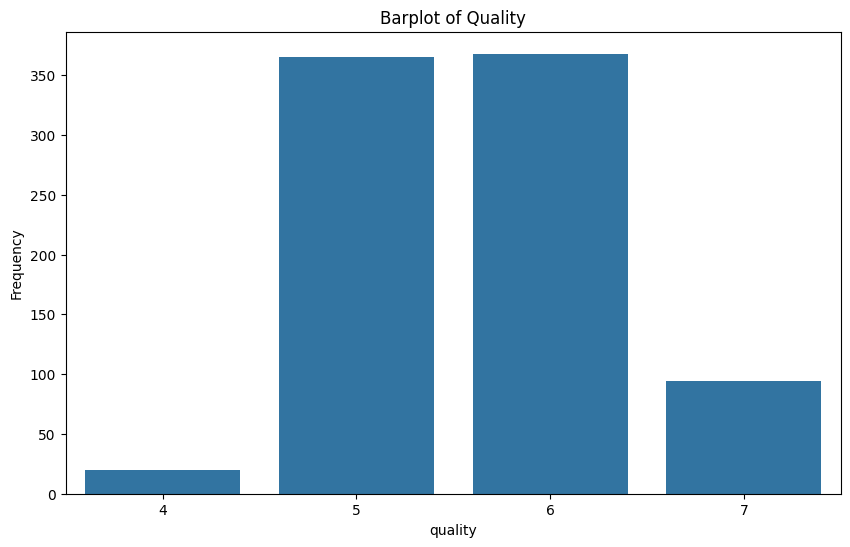

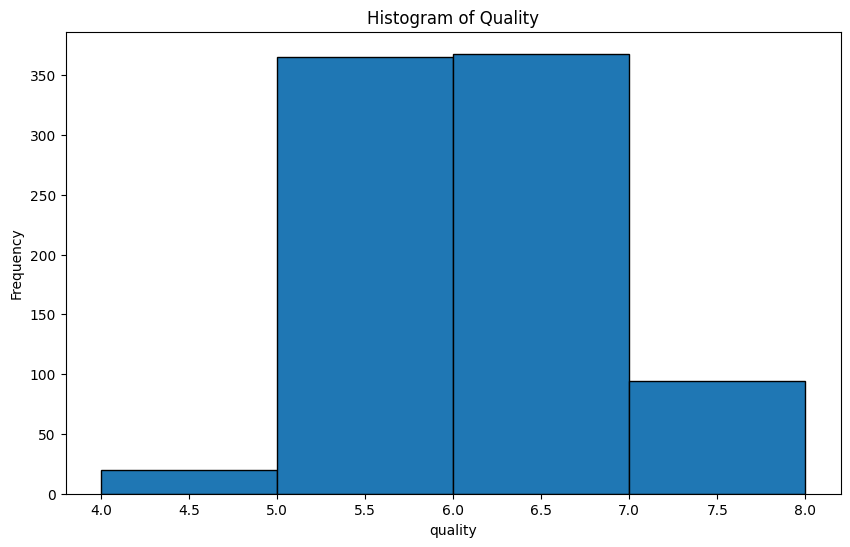

In [15]:
plt.figure(figsize=(10, 6))
sns.countplot(x='quality', data=df_cleaned)
plt.title("Barplot of Quality")
plt.xlabel("quality")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df_cleaned['quality'],
         bins=range(int(df_cleaned['quality'].min()), int(df_cleaned['quality'].max()) + 2),
         edgecolor='black')
plt.title("Histogram of Quality")
plt.xlabel("quality")
plt.ylabel("Frequency")
plt.show()
plt.show()

Dataset shape: (1143, 13)


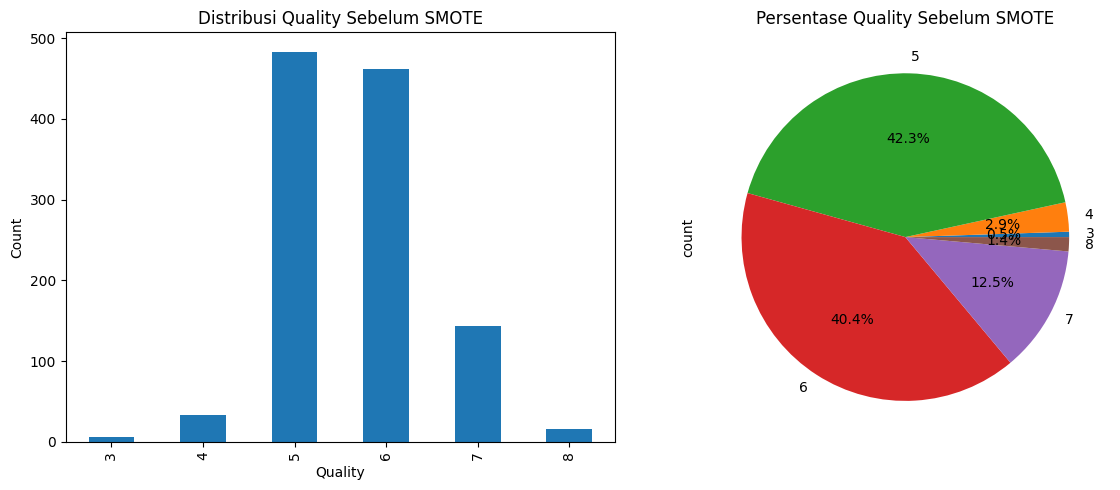


Shape X: (1143, 11)
Shape y: (1143,)
Distribusi y: Counter({5: 483, 6: 462, 7: 143, 4: 33, 8: 16, 3: 6})

APLIKASI SMOTE
Distribusi setelah SMOTE:
Counter({5: 483, 6: 483, 7: 483, 4: 483, 8: 483, 3: 483})


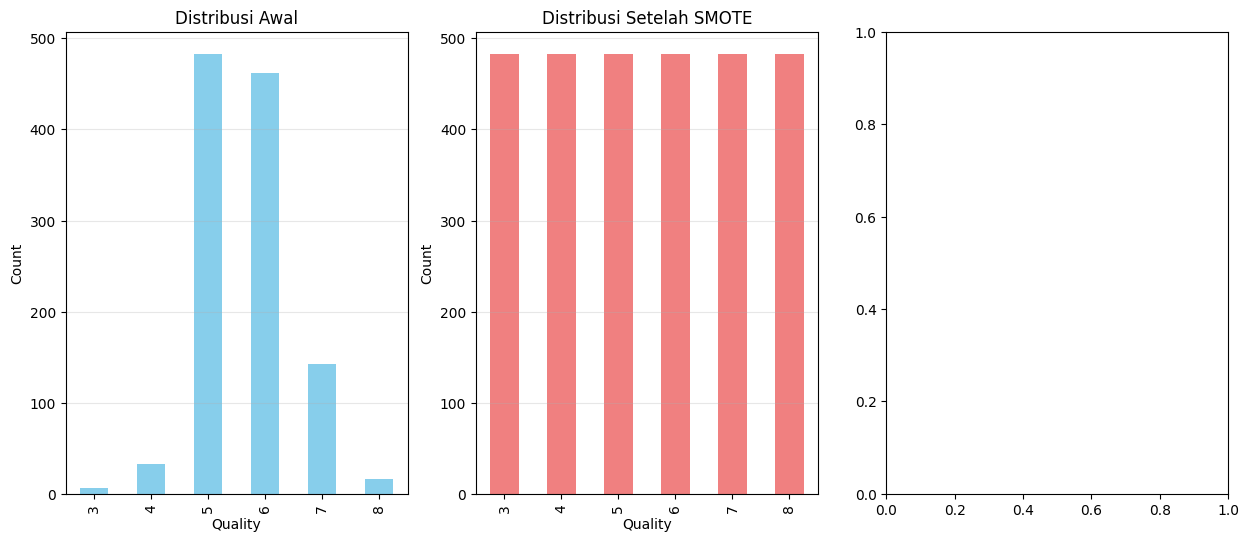

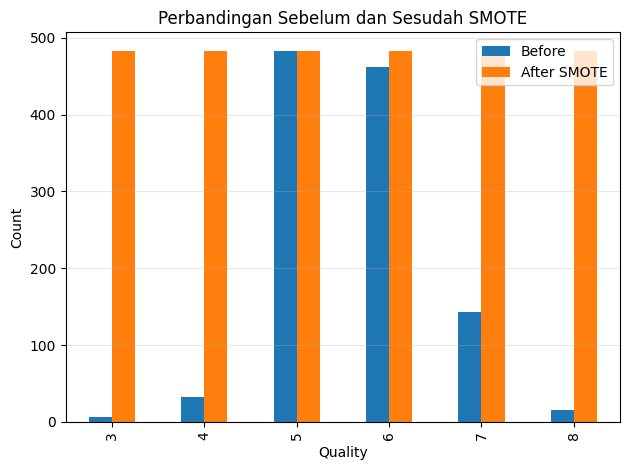


APLIKASI SMOTE-ENN
Distribusi setelah SMOTE-ENN:
Counter({3: 416, 8: 375, 7: 351, 4: 350, 5: 100, 6: 47})


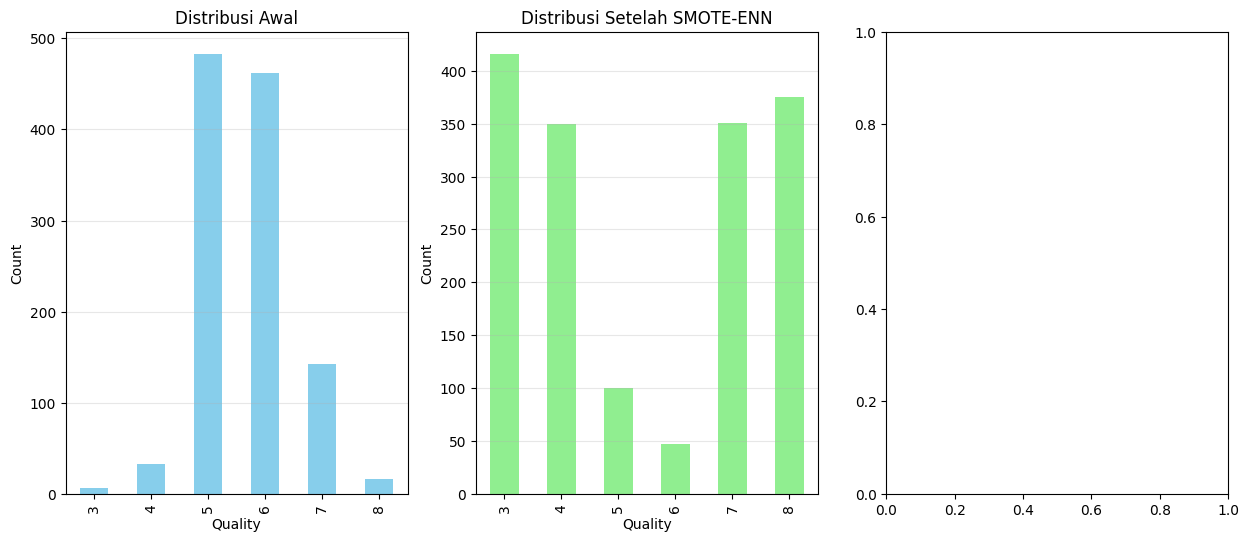

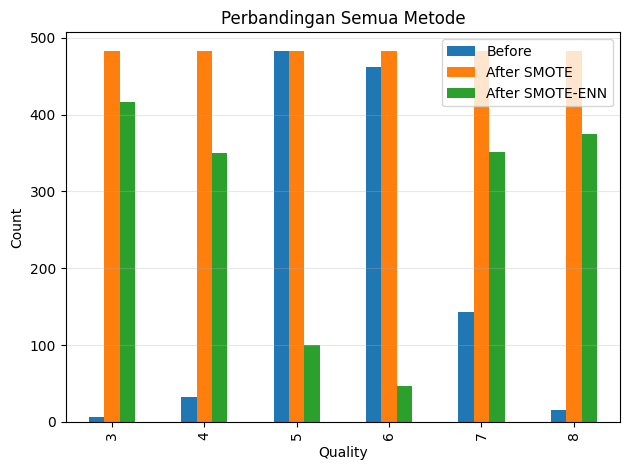


ANALISIS STATISTIK

Jumlah sampel awal: 1143
Jumlah sampel setelah SMOTE: 2898
Jumlah sampel setelah SMOTE-ENN: 1639

Rasio kelas awal:
  Quality 5: 483 (42.26%)
  Quality 6: 462 (40.42%)
  Quality 7: 143 (12.51%)
  Quality 4: 33 (2.89%)
  Quality 8: 16 (1.40%)
  Quality 3: 6 (0.52%)

Rasio kelas setelah SMOTE:
  Quality 5: 483 (16.67%)
  Quality 6: 483 (16.67%)
  Quality 7: 483 (16.67%)
  Quality 4: 483 (16.67%)
  Quality 8: 483 (16.67%)
  Quality 3: 483 (16.67%)

Rasio kelas setelah SMOTE-ENN:
  Quality 3: 416 (25.38%)
  Quality 4: 350 (21.35%)
  Quality 5: 100 (6.10%)
  Quality 6: 47 (2.87%)
  Quality 7: 351 (21.42%)
  Quality 8: 375 (22.88%)

KESIMPULAN
✓ SMOTE berhasil membuat distribusi kelas sempurna (semua kelas sama)
✗ SMOTE-ENN belum mencapai distribusi sempurna

Rekomendasi:
- Gunakan hasil SMOTE untuk training model karena distribusi sudah seimbang


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN

# Load dataset (sudah dilakukan di notebook)
df = pd.read_csv("WineQT.csv")
print("Dataset shape:", df.shape)


from collections import Counter# Visualisasi distribusi awal
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['quality'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribusi Quality Sebelum SMOTE')
plt.xlabel('Quality')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
df['quality'].value_counts().sort_index().plot(kind='pie', autopct='%1.1f%%')
plt.title('Persentase Quality Sebelum SMOTE')

plt.tight_layout()
plt.show()

# Memisahkan fitur dan target
# Hapus kolom 'Id' karena bukan fitur yang relevan
X = df.drop(['quality', 'Id'], axis=1)
y = df['quality']

print("\nShape X:", X.shape)
print("Shape y:", y.shape)
print("Distribusi y:", Counter(y))

# 1. SMOTE (Synthetic Minority Over-sampling Technique)
print("\n" + "="*50)
print("APLIKASI SMOTE")
print("="*50)

# Inisialisasi SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)

# Terapkan SMOTE
X_smote, y_smote = smote.fit_resample(X, y)

print("Distribusi setelah SMOTE:")
print(Counter(y_smote))

# Visualisasi hasil SMOTE
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
pd.Series(y).value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribusi Awal')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 3, 2)
pd.Series(y_smote).value_counts().sort_index().plot(kind='bar', color='lightcoral')
plt.title('Distribusi Setelah SMOTE')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 3, 3)
# Perbandingan
data_comparison = pd.DataFrame({
    'Before': pd.Series(y).value_counts().sort_index(),
    'After SMOTE': pd.Series(y_smote).value_counts().sort_index()
})
data_comparison.plot(kind='bar')
plt.title('Perbandingan Sebelum dan Sesudah SMOTE')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 2. SMOTE-ENN (SMOTE + Edited Nearest Neighbors)
print("\n" + "="*50)
print("APLIKASI SMOTE-ENN")
print("="*50)

# Inisialisasi SMOTE-ENN
smote_enn = SMOTEENN(random_state=42)

# Terapkan SMOTE-ENN
X_smote_enn, y_smote_enn = smote_enn.fit_resample(X, y)

print("Distribusi setelah SMOTE-ENN:")
print(Counter(y_smote_enn))

# Visualisasi hasil SMOTE-ENN
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
pd.Series(y).value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribusi Awal')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 3, 2)
pd.Series(y_smote_enn).value_counts().sort_index().plot(kind='bar', color='lightgreen')
plt.title('Distribusi Setelah SMOTE-ENN')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 3, 3)
# Perbandingan
data_comparison_all = pd.DataFrame({
    'Before': pd.Series(y).value_counts().sort_index(),
    'After SMOTE': pd.Series(y_smote).value_counts().sort_index(),
    'After SMOTE-ENN': pd.Series(y_smote_enn).value_counts().sort_index()
})
data_comparison_all.plot(kind='bar')
plt.title('Perbandingan Semua Metode')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Analisis statistik
print("\n" + "="*50)
print("ANALISIS STATISTIK")
print("="*50)

print(f"\nJumlah sampel awal: {len(y)}")
print(f"Jumlah sampel setelah SMOTE: {len(y_smote)}")
print(f"Jumlah sampel setelah SMOTE-ENN: {len(y_smote_enn)}")

print("\nRasio kelas awal:")
for kelas, count in Counter(y).items():
    persentase = (count / len(y)) * 100
    print(f"  Quality {kelas}: {count} ({persentase:.2f}%)")

print("\nRasio kelas setelah SMOTE:")
for kelas, count in Counter(y_smote).items():
    persentase = (count / len(y_smote)) * 100
    print(f"  Quality {kelas}: {count} ({persentase:.2f}%)")

print("\nRasio kelas setelah SMOTE-ENN:")
for kelas, count in Counter(y_smote_enn).items():
    persentase = (count / len(y_smote_enn)) * 100
    print(f"  Quality {kelas}: {count} ({persentase:.2f}%)")

# Simpan hasil untuk digunakan selanjutnya
# Simpan dalam dictionary
results = {
    'original': (X, y),
    'smote': (X_smote, y_smote),
    'smote_enn': (X_smote_enn, y_smote_enn)
}

print("\n" + "="*50)
print("KESIMPULAN")
print("="*50)

# Tentukan metode terbaik berdasarkan keseimbangan kelas
if len(set(Counter(y_smote).values())) == 1:
    print("✓ SMOTE berhasil membuat distribusi kelas sempurna (semua kelas sama)")
else:
    print("✗ SMOTE belum mencapai distribusi sempurna")

if len(set(Counter(y_smote_enn).values())) == 1:
    print("✓ SMOTE-ENN berhasil membuat distribusi kelas sempurna (semua kelas sama)")
else:
    print("✗ SMOTE-ENN belum mencapai distribusi sempurna")

# Rekomendasi
print("\nRekomendasi:")
if len(set(Counter(y_smote).values())) == 1:
    print("- Gunakan hasil SMOTE untuk training model karena distribusi sudah seimbang")
else:
    print("- SMOTE-ENN mungkin lebih baik karena juga membersihkan noise")